<a href="https://colab.research.google.com/github/OJB-Quantum/Monte-Carlo-Sim/blob/main/CUDA_Accelerated_SVG_PNG_to_Layout_PEC_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2025)

Open Access (CC-BY-4.0)

In [ ]:
!nvidia-smi

Fri Dec 19 16:29:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import re
import subprocess
import sys


def detect_cuda_major() -> int:
    """Detect CUDA major version from nvidia-smi output; default to 12 if unknown."""
    try:
        out = subprocess.check_output(["nvidia-smi"], text=True)
        match = re.search(r"CUDA Version:\s+(\d+)\.", out)
        if match:
            return int(match.group(1))
    except Exception:
        pass
    return 12


cuda_major = detect_cuda_major()
cupy_pkg = "cupy-cuda12x" if cuda_major >= 12 else "cupy-cuda11x"
print(f"Detected CUDA major = {cuda_major}. Installing {cupy_pkg} ...")

# System libs for SVG rasterization (cairosvg uses Cairo/Pango stack).
subprocess.check_call(["bash", "-lc", "apt-get -y update -qq"])
subprocess.check_call([
    "bash", "-lc",
    "apt-get -y install -qq libcairo2 libpango-1.0-0 libpangocairo-1.0-0"
])

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", cupy_pkg])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pillow", "cairosvg"])

print("Install complete.")


Detected CUDA major = 12. Installing cupy-cuda12x ...
Install complete.


In [ ]:
from dataclasses import dataclass
from typing import Dict, Tuple

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import cupy as cp

# Required: set DPI to 200 via Matplotlib rcParams.
mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "image.cmap": "gray",
})

print("NumPy:", np.__version__)
print("CuPy:", cp.__version__)

dev = cp.cuda.Device()
props = cp.cuda.runtime.getDeviceProperties(dev.id)
gpu_name = props["name"].decode("utf-8") if isinstance(props["name"], (bytes, bytearray)) else str(props["name"])
print("Active GPU:", gpu_name)


NumPy: 2.0.2
CuPy: 13.6.0
Active GPU: NVIDIA L4


In [ ]:
@dataclass(frozen=True)
class SimConfig:
    # Domain and rasterization
    domain_width_um: float = 6.0          # CONTROL KNOB: total horizontal length Lx
    grid_n: int = 512                     # NxN simulation grid
    shape_fill_fraction: float = 0.70     # fraction of width used by the shape (padding)
    alpha_threshold: float = 0.15         # alpha cutoff (0..1) for binary conversion
    binarize_target: bool = True          # if False, use soft alpha mask

    # Optical model
    opt_sigma_nm: float = 35.0
    opt_threshold: float = 0.50
    opt_sigmoid_slope: float = 0.08
    opt_photons_per_pixel: float = 800.0
    opt_opc_iters: int = 60
    opt_opc_step: float = 0.50

    # E-beam model
    eb_sigma_f_nm: float = 12.0
    eb_sigma_b_nm: float = 140.0
    eb_eta: float = 0.20
    eb_threshold: float = 0.50
    eb_reg_lambda: float = 3.0e-3
    eb_dose_clip: float = 3.0

    # Monte Carlo
    mc_electrons_total: int = 2_000_000
    mc_chunk_size: int = 400_000

    # RNG
    seed: int = 7

    # SVG rasterization
    svg_raster_width_px: int = 2048      # Larger preserves more geometric detail


CFG = SimConfig()


def domain_width_nm(cfg: SimConfig) -> float:
    return float(cfg.domain_width_um) * 1000.0


def pixel_nm(cfg: SimConfig) -> float:
    return domain_width_nm(cfg) / float(cfg.grid_n)


print("Derived pixel size (nm/pixel):", pixel_nm(CFG))
print("Domain width (nm):", domain_width_nm(CFG))


Derived pixel size (nm/pixel): 11.71875
Domain width (nm): 6000.0


Saving IBM_logo.svg to IBM_logo.svg
Uploaded: IBM_logo.svg


/tmp/ipython-input-1406209408.py:69: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  alpha_img = Image.fromarray((alpha_crop * 255.0).astype(np.uint8), mode="L")


Rasterization summary: {'orig_h': 764, 'orig_w': 2048, 'crop_h': 764, 'crop_w': 2046, 'resized_h': 134, 'resized_w': 358, 'y_off': 189, 'x_off': 77}
Target mask stats: min= 0.0 max= 1.0 mean= 0.07366561889648438


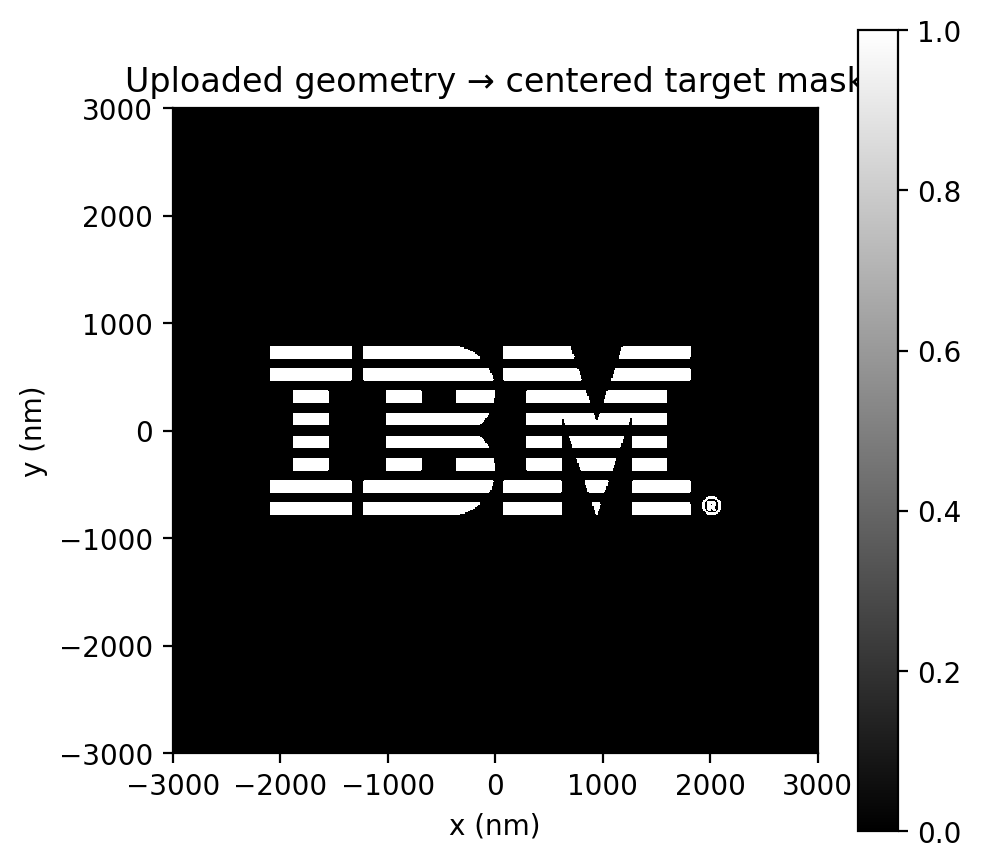

In [ ]:
from google.colab import files
import cairosvg
import io
import os


def _load_rgba_image_from_upload(filename: str, cfg: SimConfig) -> Image.Image:
    """
    Load uploaded SVG/PNG into a PIL RGBA image.
    - SVG is rasterized to PNG using cairosvg.
    - PNG is loaded directly.
    """
    ext = os.path.splitext(filename)[1].lower().strip()

    if ext == ".svg":
        with open(filename, "rb") as f:
            svg_bytes = f.read()
        png_bytes = cairosvg.svg2png(
            bytestring=svg_bytes,
            output_width=int(cfg.svg_raster_width_px),
        )
        img = Image.open(io.BytesIO(png_bytes)).convert("RGBA")
        return img

    if ext == ".png":
        img = Image.open(filename).convert("RGBA")
        return img

    raise ValueError(f"Unsupported file type: {ext}. Please upload an SVG or PNG.")


def _alpha_to_mask_cpu(
    rgba: Image.Image,
    cfg: SimConfig,
) -> Tuple[np.ndarray, Dict[str, int]]:
    """
    Convert RGBA image to a centered NxN target mask on CPU.
    Returns (mask_float32, debug_info).
    """
    arr = np.asarray(rgba, dtype=np.uint8)
    if arr.ndim != 3 or arr.shape[2] != 4:
        raise ValueError("Expected an RGBA image with an alpha channel.")

    alpha = arr[:, :, 3].astype(np.float32) / 255.0

    # Find bounding box of "nontransparent" pixels.
    keep = alpha > float(cfg.alpha_threshold)
    if not np.any(keep):
        raise ValueError(
            "No pixels exceeded alpha_threshold. "
            "Try lowering alpha_threshold, or verify the artwork has nonzero alpha."
        )

    ys, xs = np.where(keep)
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1

    alpha_crop = alpha[y0:y1, x0:x1]

    # Resize to fit within shape_fill_fraction * grid_n while preserving aspect ratio.
    ny, nx = alpha_crop.shape
    max_w = max(1, int(round(cfg.shape_fill_fraction * cfg.grid_n)))
    max_h = max_w  # keep it square-fit, but aspect is preserved by scaling on the limiting dimension

    scale = min(max_w / float(nx), max_h / float(ny))
    new_w = max(1, int(round(nx * scale)))
    new_h = max(1, int(round(ny * scale)))

    alpha_img = Image.fromarray((alpha_crop * 255.0).astype(np.uint8), mode="L")
    alpha_rs = alpha_img.resize((new_w, new_h), resample=Image.Resampling.LANCZOS)
    alpha_rs = np.asarray(alpha_rs, dtype=np.float32) / 255.0

    if cfg.binarize_target:
        mask_small = (alpha_rs > float(cfg.alpha_threshold)).astype(np.float32)
    else:
        # Soft target: preserves antialiasing as fractional coverage.
        mask_small = np.clip(alpha_rs, 0.0, 1.0).astype(np.float32)

    # Center into NxN canvas.
    N = int(cfg.grid_n)
    canvas = np.zeros((N, N), dtype=np.float32)
    y_off = (N - new_h) // 2
    x_off = (N - new_w) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = mask_small

    debug = {
        "orig_h": int(rgba.size[1]),
        "orig_w": int(rgba.size[0]),
        "crop_h": int(ny),
        "crop_w": int(nx),
        "resized_h": int(new_h),
        "resized_w": int(new_w),
        "y_off": int(y_off),
        "x_off": int(x_off),
    }
    return canvas, debug


# --- Upload prompt ---
uploaded = files.upload()
if len(uploaded) < 1:
    raise RuntimeError("No file uploaded.")

filename = next(iter(uploaded.keys()))
print("Uploaded:", filename)

rgba_img = _load_rgba_image_from_upload(filename, CFG)
target_cpu, dbg = _alpha_to_mask_cpu(rgba_img, CFG)

print("Rasterization summary:", dbg)
print("Target mask stats:",
      "min=", float(target_cpu.min()),
      "max=", float(target_cpu.max()),
      "mean=", float(target_cpu.mean()))

# Move target to GPU
target = cp.asarray(target_cpu, dtype=cp.float32)

# Quick preview
extent_nm = domain_width_nm(CFG)
plt.figure(figsize=(5.2, 5.2))
plt.title("Uploaded geometry → centered target mask")
plt.imshow(target_cpu, extent=[-extent_nm/2, extent_nm/2, -extent_nm/2, extent_nm/2], interpolation="nearest")
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.colorbar()
plt.show()


In [ ]:
def gaussian_psf(shape: Tuple[int, int], sigma_px: float) -> cp.ndarray:
    """Centered 2D Gaussian PSF normalized to sum=1."""
    ny, nx = shape
    y = cp.arange(ny) - ny // 2
    x = cp.arange(nx) - nx // 2
    yy, xx = cp.meshgrid(y, x, indexing="ij")
    psf = cp.exp(-(xx**2 + yy**2) / (2.0 * float(sigma_px)**2))
    psf = psf / cp.sum(psf)
    return psf.astype(cp.float32)


def double_gaussian_psf(
    shape: Tuple[int, int],
    sigma_f_px: float,
    sigma_b_px: float,
    eta: float,
) -> cp.ndarray:
    """Mixture PSF: (1-eta)G(sigma_f) + eta G(sigma_b), normalized."""
    psf_f = gaussian_psf(shape, sigma_f_px)
    psf_b = gaussian_psf(shape, sigma_b_px)
    psf = (1.0 - float(eta)) * psf_f + float(eta) * psf_b
    psf = psf / cp.sum(psf)
    return psf.astype(cp.float32)


def psf_fft(psf: cp.ndarray) -> cp.ndarray:
    """FFT of a centered PSF (ifftshift so convolution aligns correctly)."""
    return cp.fft.fft2(cp.fft.ifftshift(psf))


def fft_convolve2d(img: cp.ndarray, psf_f: cp.ndarray) -> cp.ndarray:
    """2D convolution using FFT."""
    out = cp.fft.ifft2(cp.fft.fft2(img) * psf_f)
    return cp.real(out).astype(cp.float32)


# Physical → pixel conversion derived from domain width knob
px_nm = pixel_nm(CFG)
N = CFG.grid_n

# Optical PSF
opt_sigma_px = float(CFG.opt_sigma_nm) / float(px_nm)
opt_psf = gaussian_psf((N, N), opt_sigma_px)
opt_psf_f = psf_fft(opt_psf)

# E-beam PSF
eb_sigma_f_px = float(CFG.eb_sigma_f_nm) / float(px_nm)
eb_sigma_b_px = float(CFG.eb_sigma_b_nm) / float(px_nm)
eb_psf = double_gaussian_psf((N, N), eb_sigma_f_px, eb_sigma_b_px, CFG.eb_eta)
eb_psf_f = psf_fft(eb_psf)

print("Derived pixel size (nm/px):", px_nm)
print("Optical sigma (px):", opt_sigma_px)
print("E-beam sigma_f (px):", eb_sigma_f_px)
print("E-beam sigma_b (px):", eb_sigma_b_px)


Derived pixel size (nm/px): 11.71875
Optical sigma (px): 2.986666666666667
E-beam sigma_f (px): 1.024
E-beam sigma_b (px): 11.946666666666667


In [ ]:
def sigmoid(x: cp.ndarray) -> cp.ndarray:
    return 1.0 / (1.0 + cp.exp(-x))


def simulate_optical_monte_carlo(
    mask: cp.ndarray,
    psf_f: cp.ndarray,
    photons_per_pixel: float,
    threshold: float,
    seed: int,
) -> Tuple[cp.ndarray, cp.ndarray, cp.ndarray]:
    """
    expected aerial = conv(mask, PSF)
    noisy aerial ~ Poisson(photons_per_pixel * expected) / photons_per_pixel
    printed = noisy >= threshold
    """
    expected = fft_convolve2d(mask, psf_f)
    expected = cp.clip(expected, 0.0, 1.0)

    rng = cp.random.default_rng(seed)
    lam = cp.clip(expected * float(photons_per_pixel), 0.0, None)
    counts = rng.poisson(lam=lam)
    noisy = counts.astype(cp.float32) / float(photons_per_pixel)

    printed = (noisy >= float(threshold)).astype(cp.float32)
    return expected, noisy, printed


def opc_ilt_grayscale(
    target_binary: cp.ndarray,
    psf_f: cp.ndarray,
    threshold: float,
    slope: float,
    iters: int,
    step: float,
    seed: int,
) -> cp.ndarray:
    """
    Simplified ILT-style OPC:
      printed_soft = sigmoid((conv(mask)-thr)/slope)
      minimize 0.5||printed_soft - target||^2 by gradient descent
    """
    rng = cp.random.default_rng(seed)

    mask = target_binary.astype(cp.float32).copy()
    mask = cp.clip(mask + 0.01 * rng.standard_normal(mask.shape, dtype=cp.float32), 0.0, 1.0)

    thr = float(threshold)
    sl = float(slope)

    for _ in range(int(iters)):
        aerial = fft_convolve2d(mask, psf_f)
        printed_soft = sigmoid((aerial - thr) / sl)

        error = printed_soft - target_binary
        dprinted_daerial = (printed_soft * (1.0 - printed_soft)) / sl
        grad_aerial = error * dprinted_daerial

        # Symmetric PSF → adjoint approximated by convolution with PSF
        grad_mask = fft_convolve2d(grad_aerial, psf_f)

        mask = cp.clip(mask - float(step) * grad_mask, 0.0, 1.0)

    return mask


# Optical: uncorrected
opt_expected_unc, opt_noisy_unc, opt_print_unc = simulate_optical_monte_carlo(
    mask=target,
    psf_f=opt_psf_f,
    photons_per_pixel=CFG.opt_photons_per_pixel,
    threshold=CFG.opt_threshold,
    seed=CFG.seed,
)

# Optical: corrected (OPC surrogate)
opt_mask_corr = opc_ilt_grayscale(
    target_binary=target,
    psf_f=opt_psf_f,
    threshold=CFG.opt_threshold,
    slope=CFG.opt_sigmoid_slope,
    iters=CFG.opt_opc_iters,
    step=CFG.opt_opc_step,
    seed=CFG.seed,
)

opt_expected_cor, opt_noisy_cor, opt_print_cor = simulate_optical_monte_carlo(
    mask=opt_mask_corr,
    psf_f=opt_psf_f,
    photons_per_pixel=CFG.opt_photons_per_pixel,
    threshold=CFG.opt_threshold,
    seed=CFG.seed + 1,
)


In [ ]:
def tikhonov_deconvolution_dose(
    target_energy: cp.ndarray,
    psf_f: cp.ndarray,
    reg_lambda: float,
    dose_clip: float,
) -> cp.ndarray:
    """
    Regularized inverse filtering in frequency domain:
      dose_hat = target_hat * conj(psf_hat) / (|psf_hat|^2 + lambda)
    """
    target_energy = target_energy.astype(cp.float32, copy=False)

    y_f = cp.fft.fft2(target_energy)
    h_f = psf_f
    denom = (cp.abs(h_f) ** 2) + float(reg_lambda)

    x_f = y_f * cp.conj(h_f) / denom
    dose = cp.real(cp.fft.ifft2(x_f)).astype(cp.float32, copy=False)
    return cp.clip(dose, 0.0, float(dose_clip))


def _rng_uniform(rng: object, size: int) -> cp.ndarray:
    if hasattr(rng, "random"):
        u = rng.random(size)
    else:
        u = cp.random.random(size)
    return u.astype(cp.float32, copy=False)


def _rng_standard_normal(rng: object, size: int) -> cp.ndarray:
    if hasattr(rng, "standard_normal"):
        z = rng.standard_normal(size)
    elif hasattr(rng, "normal"):
        z = rng.normal(0.0, 1.0, size=size)
    else:
        z = cp.random.standard_normal(size)
    return z.astype(cp.float32, copy=False)


def mc_ebeam_deposited_energy(
    dose: cp.ndarray,
    sigma_f_px: float,
    sigma_b_px: float,
    eta: float,
    n_electrons_total: int,
    chunk_size: int,
    seed: int,
) -> cp.ndarray:
    """
    Mixture-Gaussian landing Monte Carlo:
      base pixel ~ dose
      scatter displacement ~ (1-eta)N(0,sf) + eta N(0,sb)
      histogram landings on GPU
    """
    ny, nx = dose.shape
    n_pix = int(ny * nx)

    weights = cp.clip(dose.ravel(), 0.0, None).astype(cp.float32, copy=False)
    total_weight = float(cp.sum(weights).get())
    if total_weight <= 0.0:
        raise ValueError("Dose sum is zero; cannot run Monte Carlo sampling.")

    cdf = cp.cumsum(weights)
    cdf_total = cdf[-1]

    rng = cp.random.default_rng(seed)
    counts_total = cp.zeros((n_pix,), dtype=cp.int64)

    eta_f = float(eta)
    sf = float(sigma_f_px)
    sb = float(sigma_b_px)

    n_done = 0
    n_electrons_total = int(n_electrons_total)

    while n_done < n_electrons_total:
        m = int(min(int(chunk_size), n_electrons_total - n_done))

        u = _rng_uniform(rng, m) * cdf_total
        base_idx = cp.searchsorted(cdf, u).astype(cp.int32, copy=False)

        y0 = base_idx // nx
        x0 = base_idx - y0 * nx

        choose_back = (_rng_uniform(rng, m) < eta_f)
        sigma = cp.where(choose_back, sb, sf).astype(cp.float32, copy=False)

        dx = _rng_standard_normal(rng, m) * sigma
        dy = _rng_standard_normal(rng, m) * sigma

        x1 = cp.clip(x0 + cp.rint(dx).astype(cp.int32, copy=False), 0, nx - 1)
        y1 = cp.clip(y0 + cp.rint(dy).astype(cp.int32, copy=False), 0, ny - 1)

        landed_idx = (y1 * nx + x1).astype(cp.int32, copy=False)
        counts_chunk = cp.bincount(landed_idx, minlength=n_pix)

        counts_total += counts_chunk
        n_done += m

    energy_mc = counts_total.astype(cp.float32, copy=False).reshape((ny, nx))
    energy_mc *= (total_weight / float(n_electrons_total))
    return energy_mc


# E-beam: uncorrected dose (use target as a baseline dose map)
eb_dose_unc = target.copy()

# Expected deposited energy (deterministic convolution)
eb_energy_expected_unc = fft_convolve2d(eb_dose_unc, eb_psf_f)

# Monte Carlo deposited energy
eb_energy_mc_unc = mc_ebeam_deposited_energy(
    dose=eb_dose_unc,
    sigma_f_px=eb_sigma_f_px,
    sigma_b_px=eb_sigma_b_px,
    eta=CFG.eb_eta,
    n_electrons_total=CFG.mc_electrons_total,
    chunk_size=CFG.mc_chunk_size,
    seed=CFG.seed,
)

# E-beam: PEC corrected dose
eb_dose_cor = tikhonov_deconvolution_dose(
    target_energy=target,
    psf_f=eb_psf_f,
    reg_lambda=CFG.eb_reg_lambda,
    dose_clip=CFG.eb_dose_clip,
)

eb_energy_expected_cor = fft_convolve2d(eb_dose_cor, eb_psf_f)
eb_energy_mc_cor = mc_ebeam_deposited_energy(
    dose=eb_dose_cor,
    sigma_f_px=eb_sigma_f_px,
    sigma_b_px=eb_sigma_b_px,
    eta=CFG.eb_eta,
    n_electrons_total=CFG.mc_electrons_total,
    chunk_size=CFG.mc_chunk_size,
    seed=CFG.seed + 1,
)

# Thresholded "printed" patterns
eb_print_unc = (eb_energy_mc_unc >= CFG.eb_threshold).astype(cp.float32)
eb_print_cor = (eb_energy_mc_cor >= CFG.eb_threshold).astype(cp.float32)


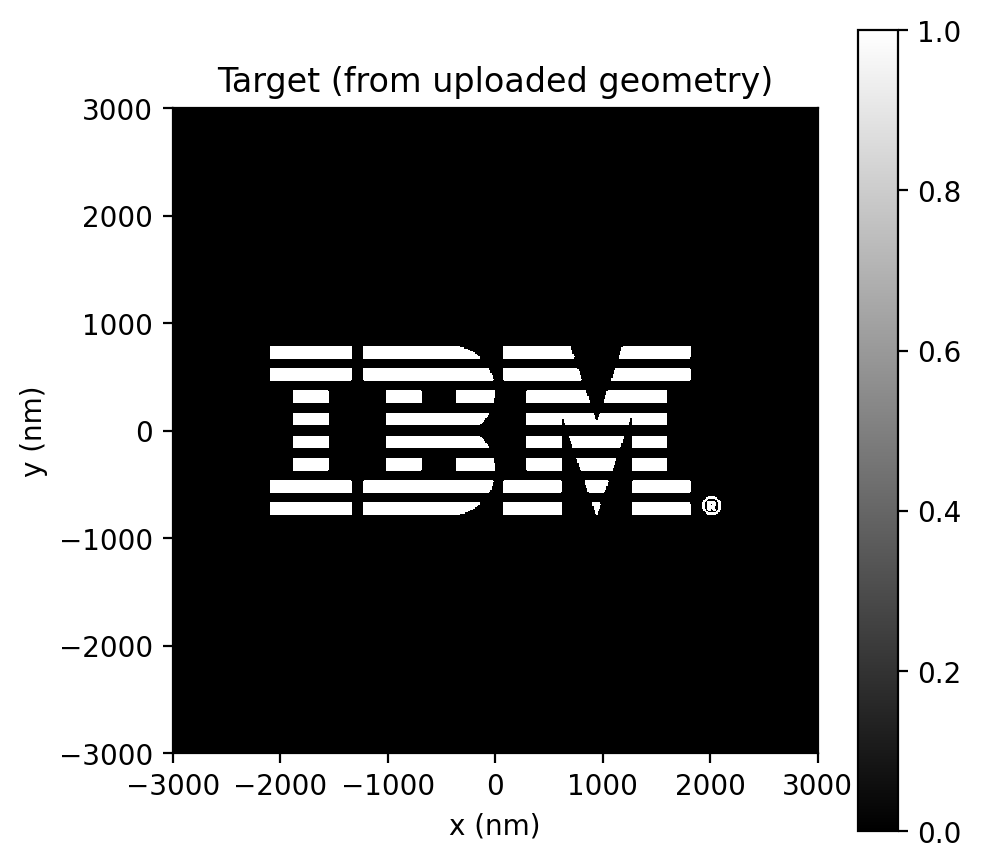

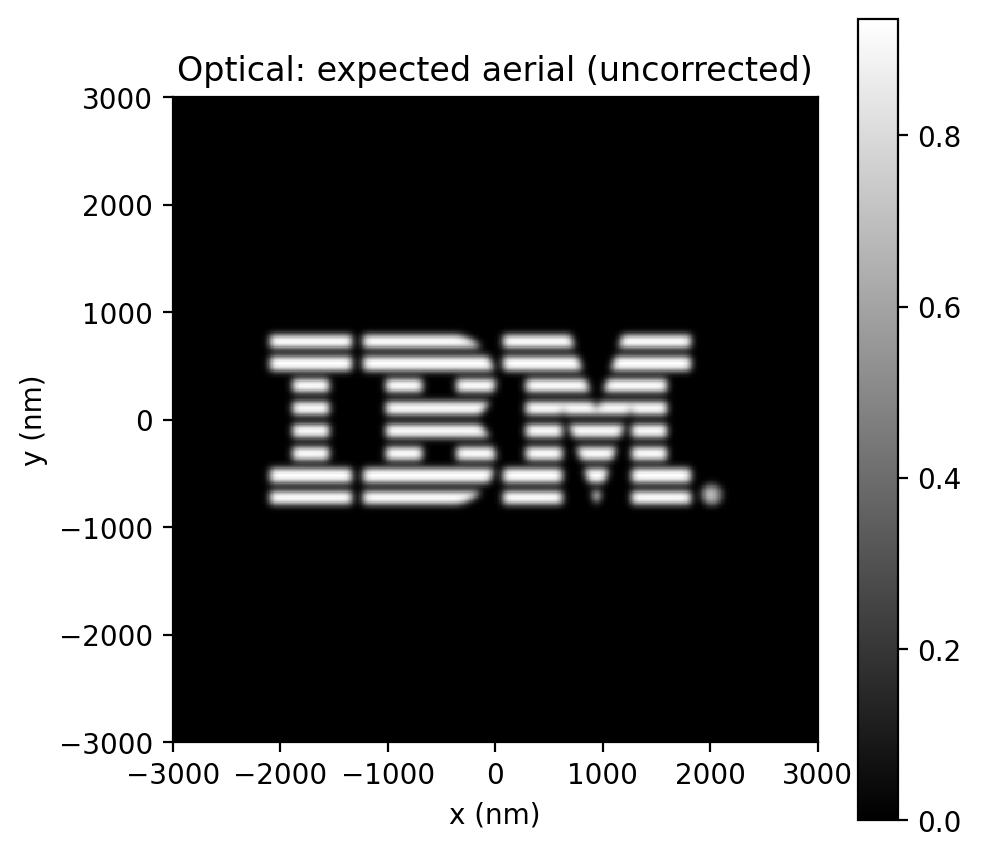

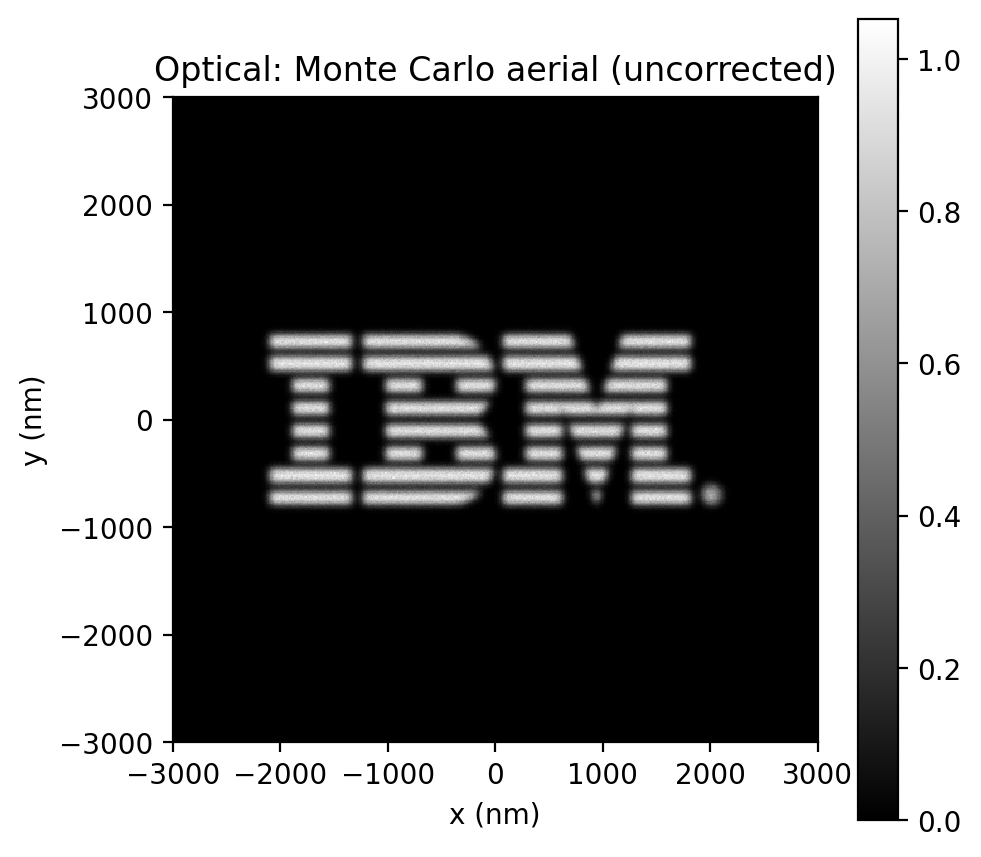

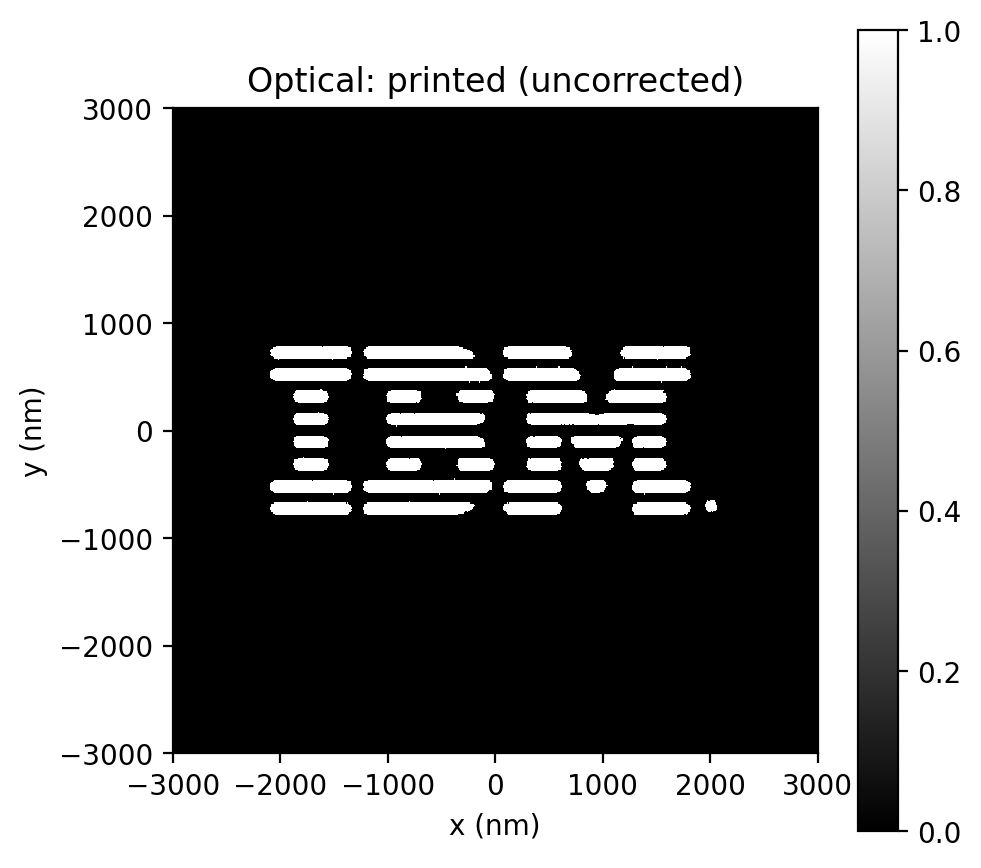

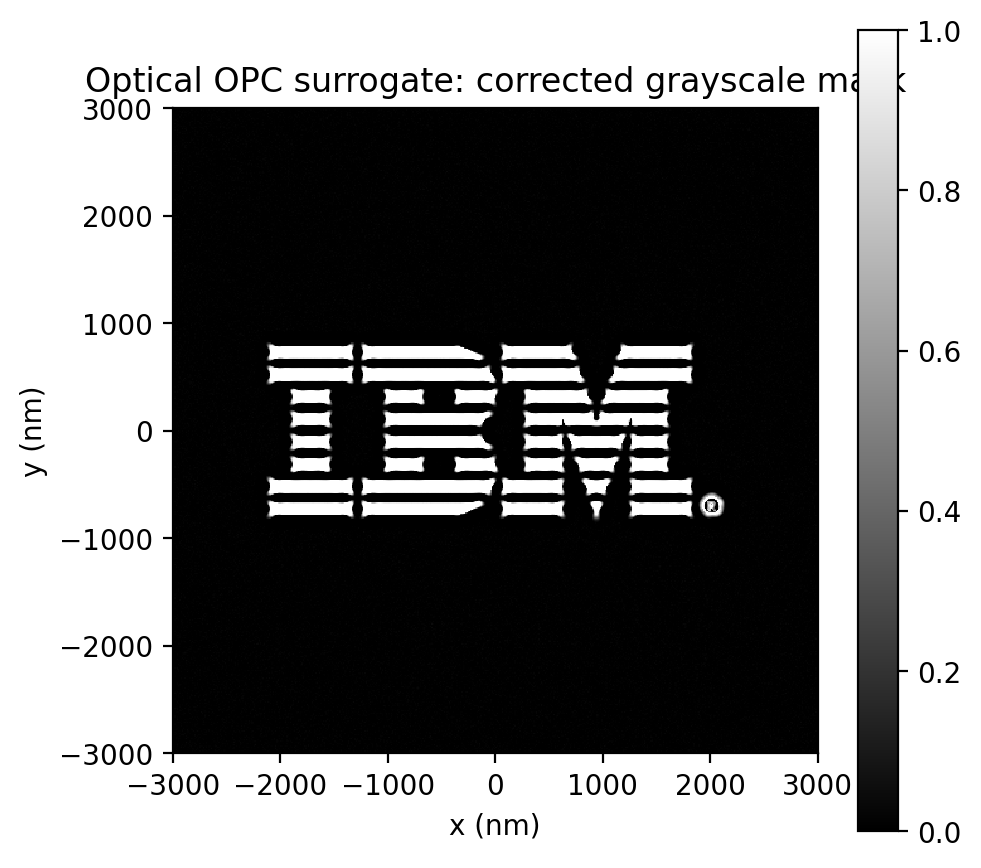

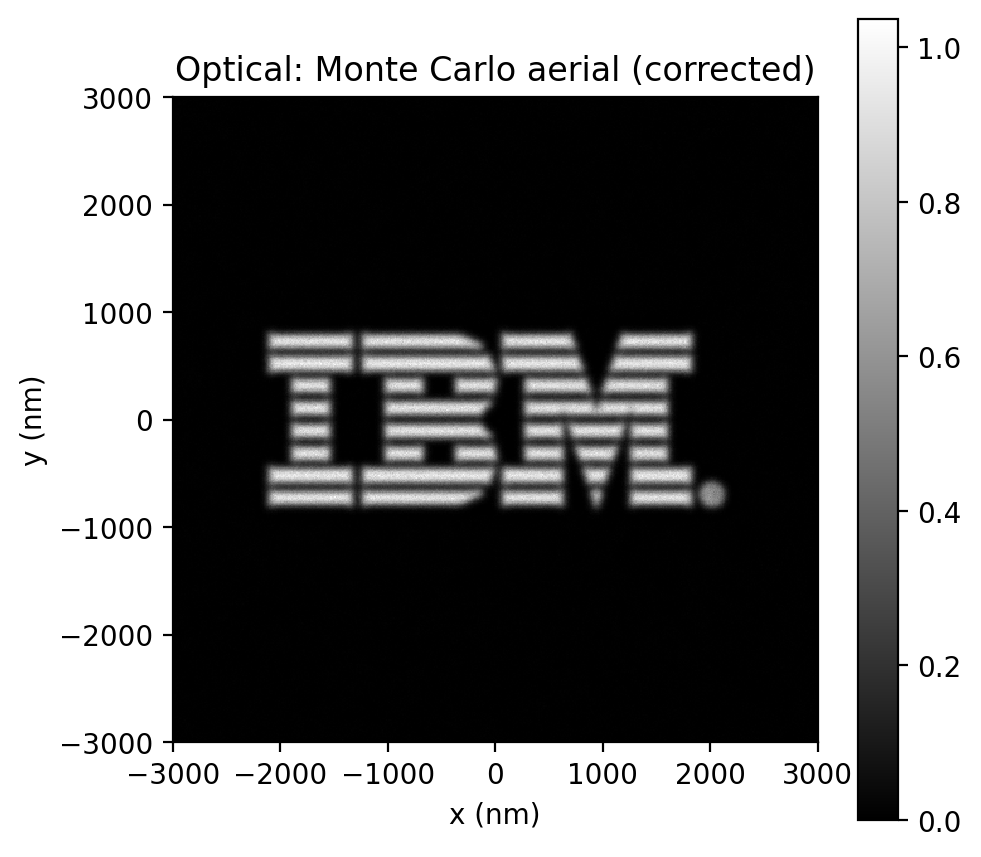

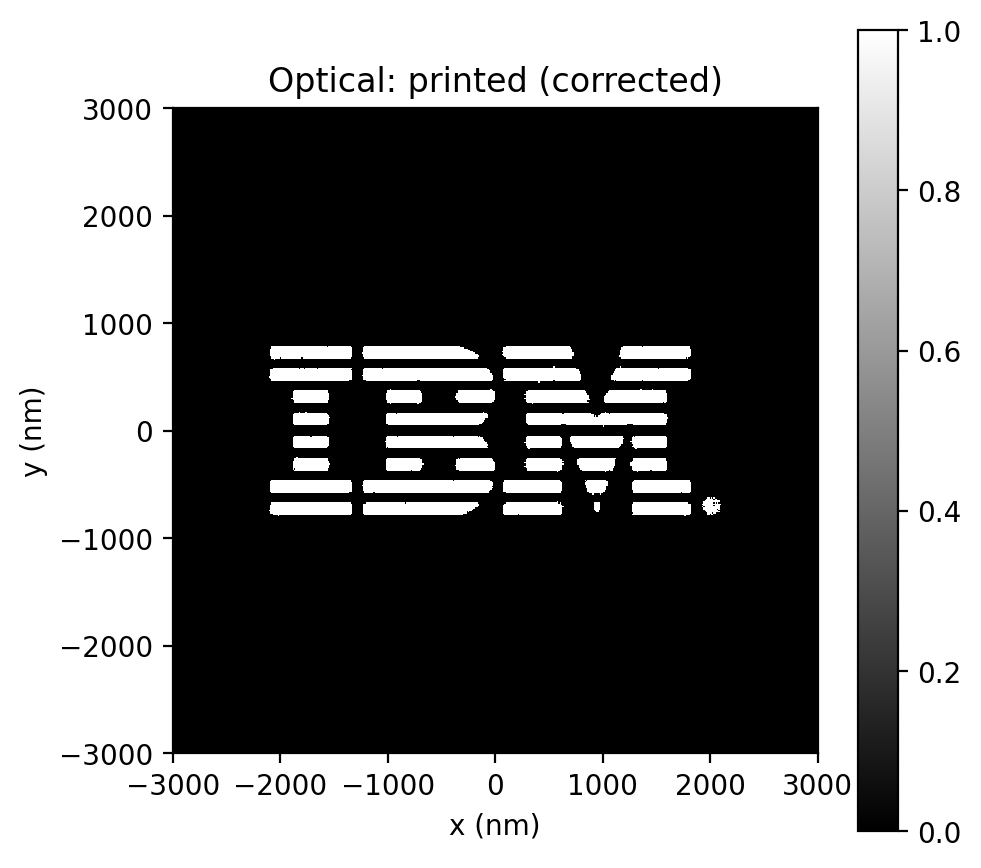

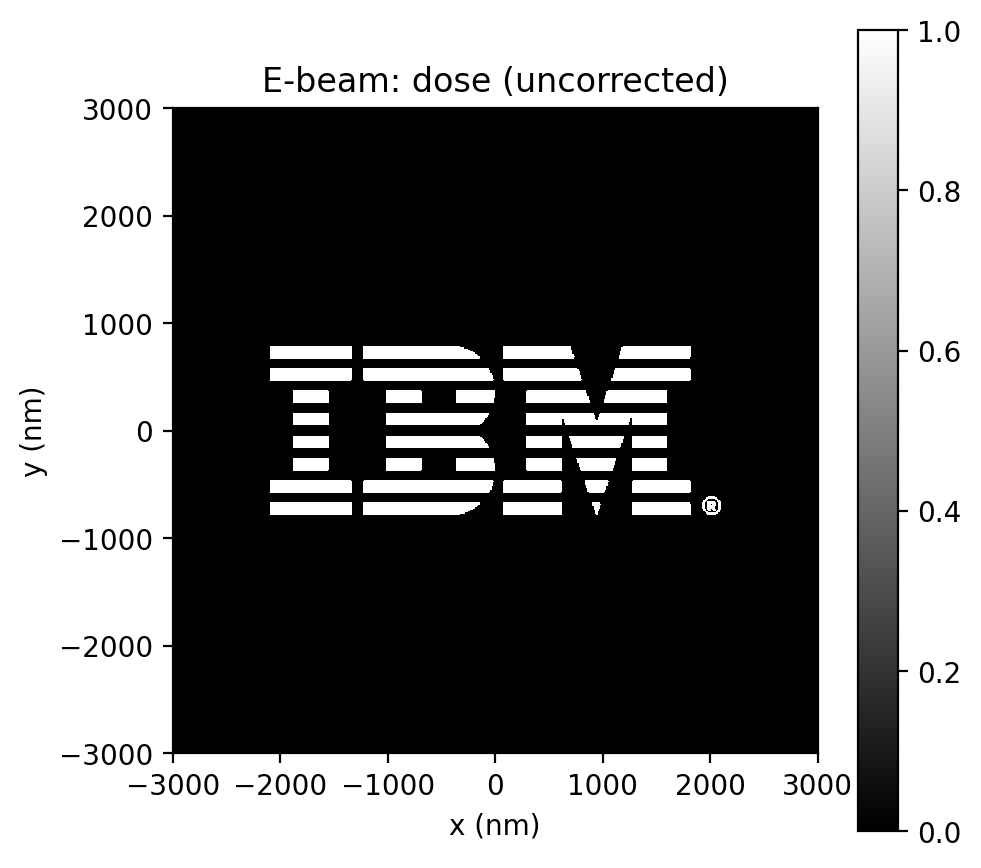

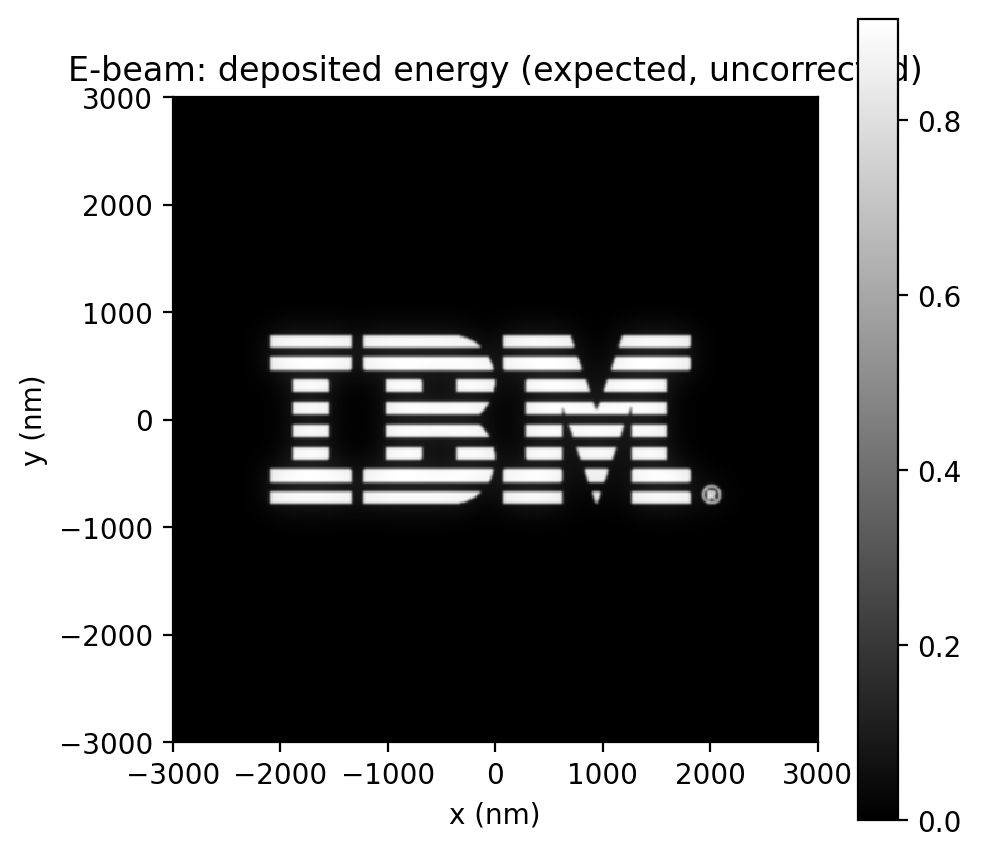

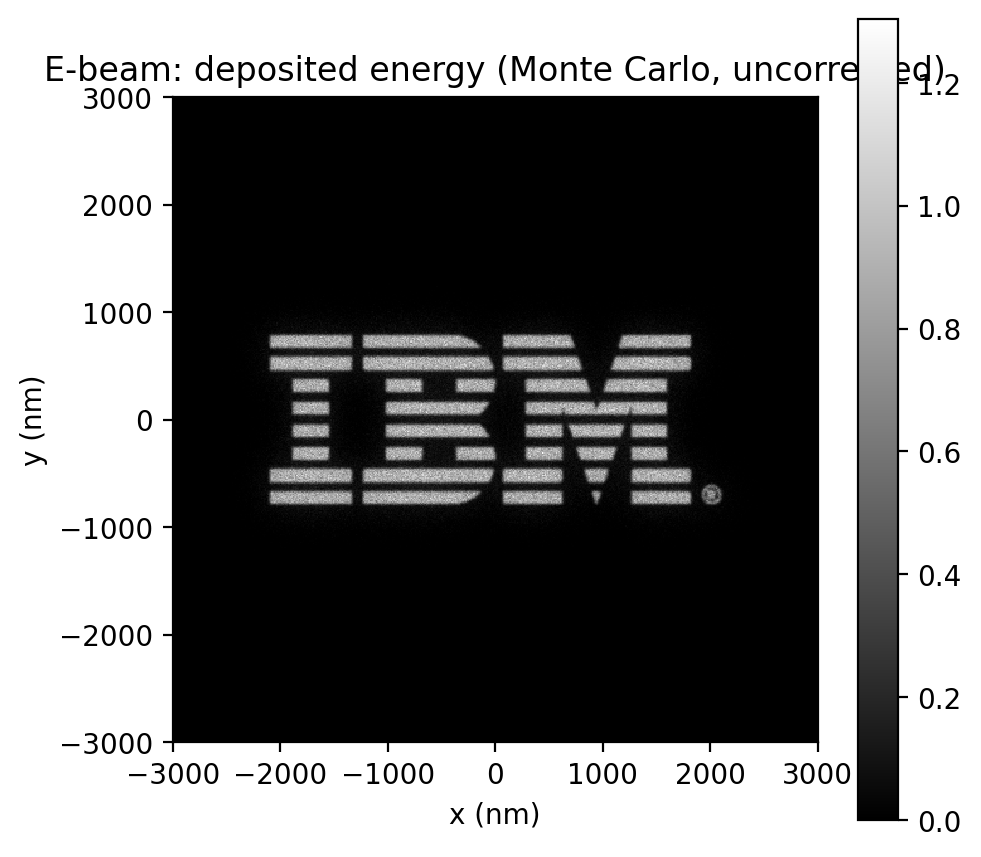

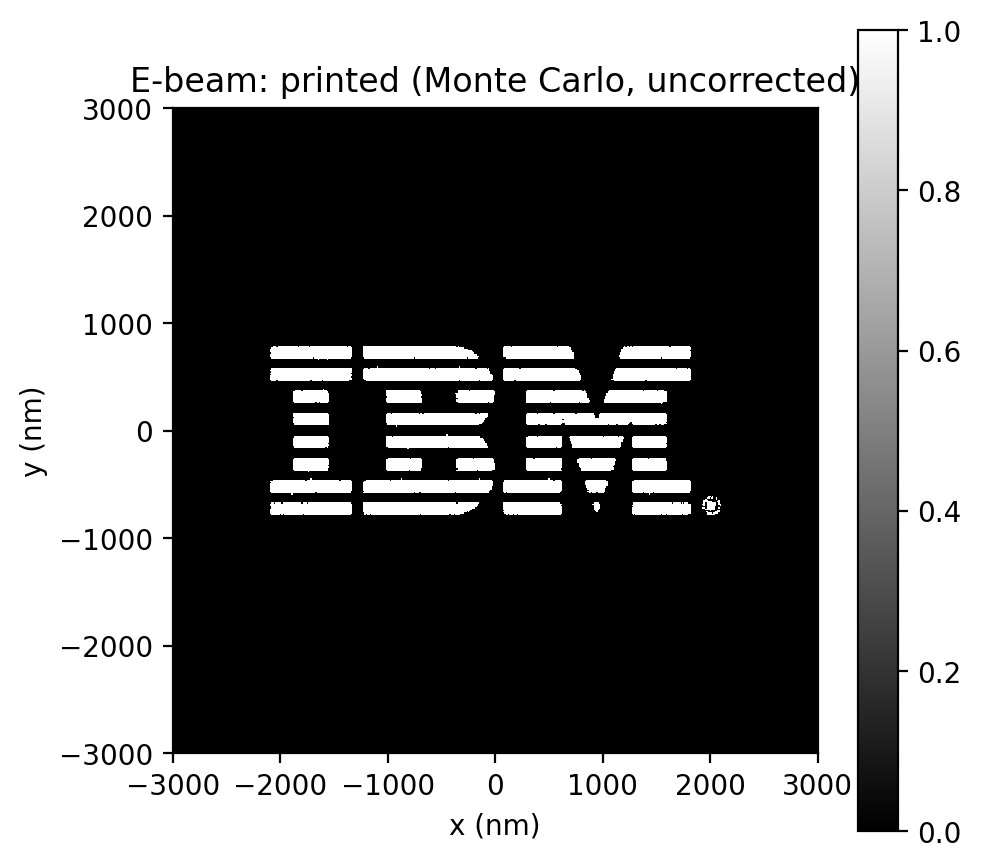

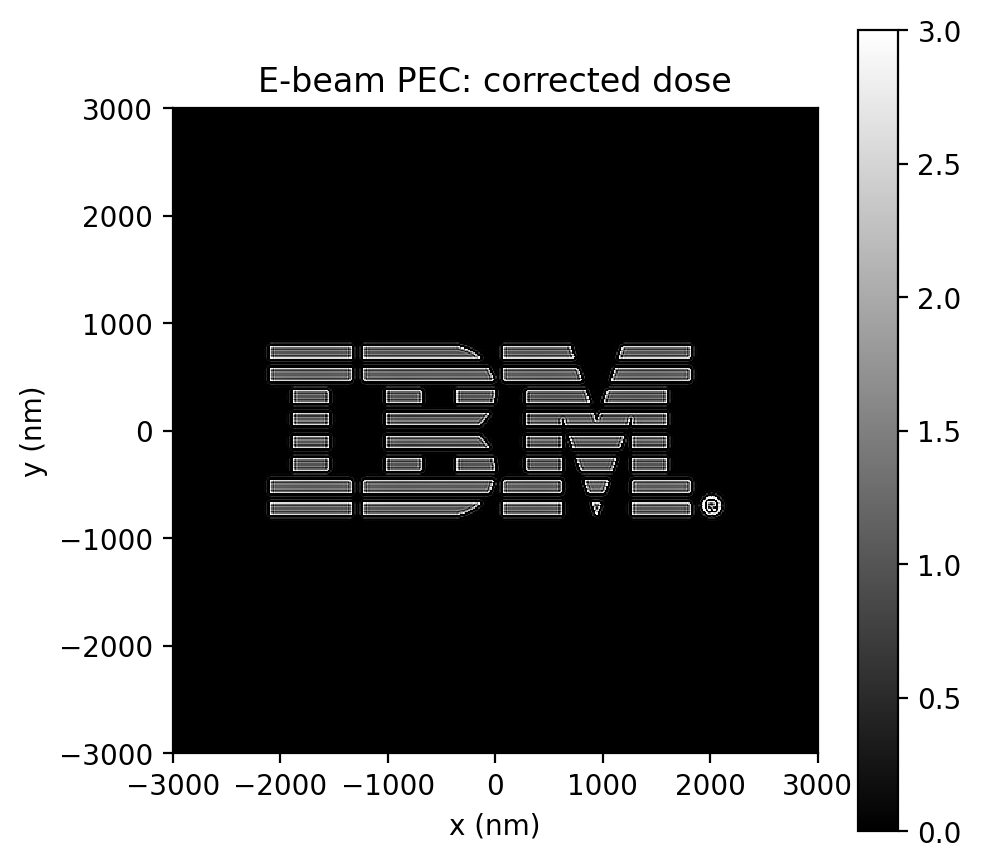

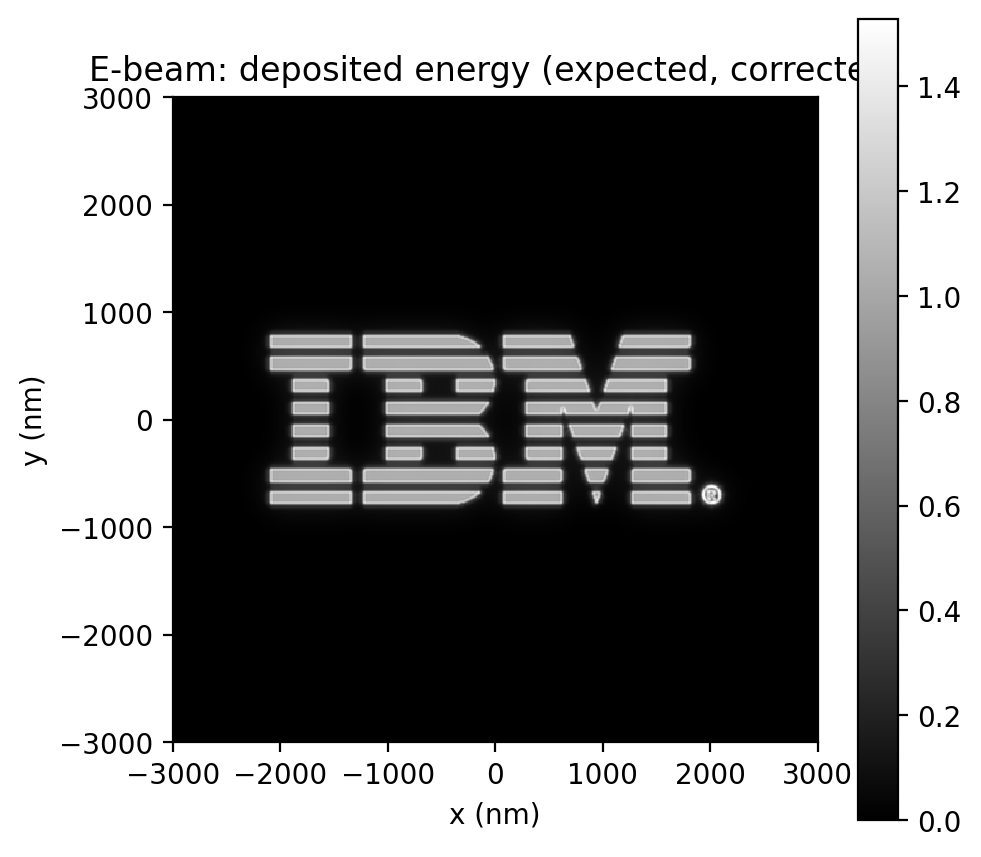

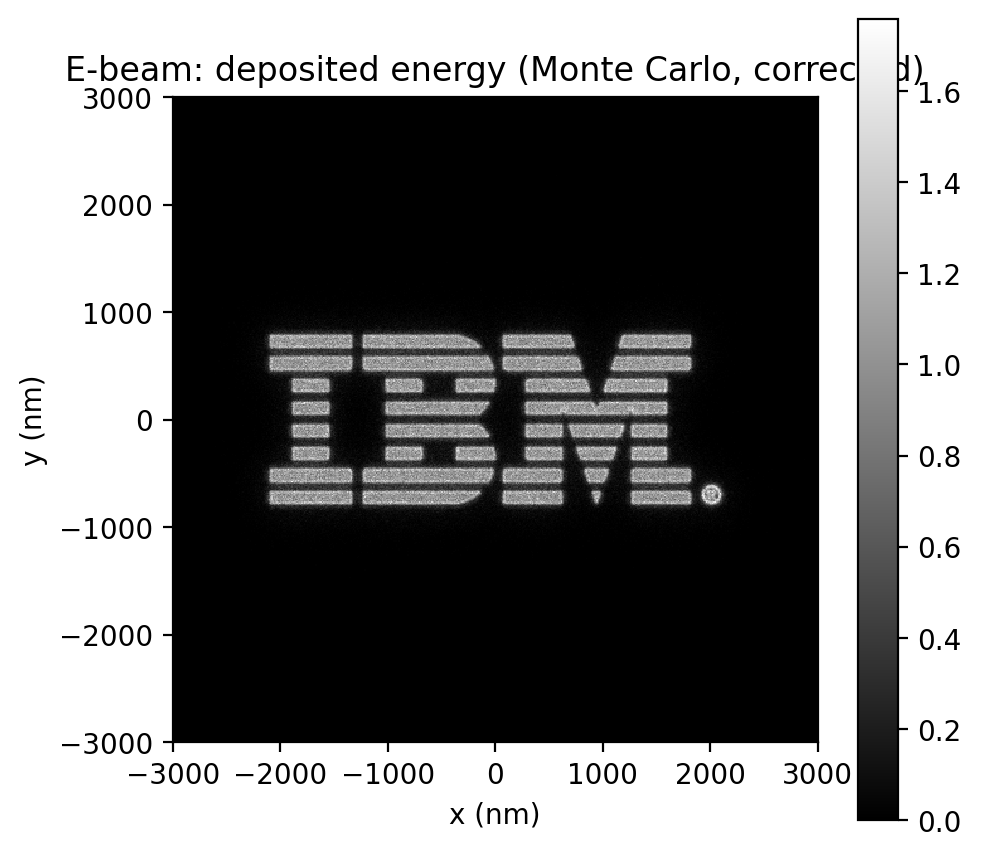

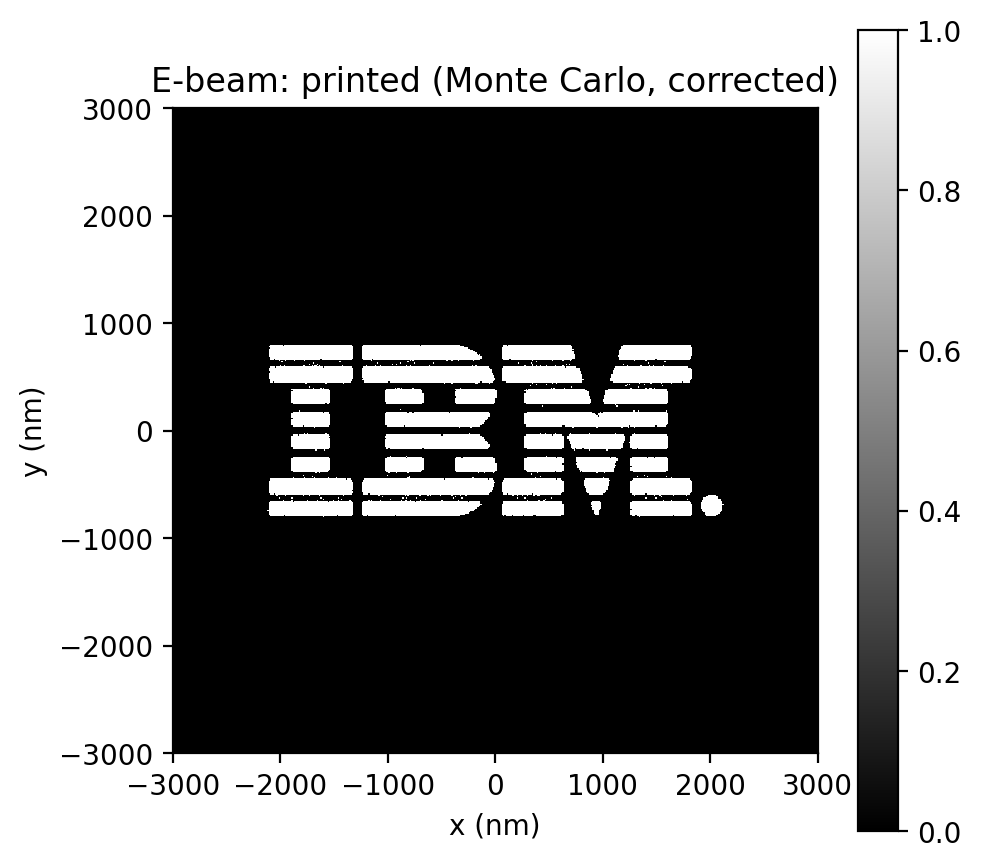

In [ ]:
def to_cpu(x):
    return cp.asnumpy(x) if isinstance(x, cp.ndarray) else x


def show_image(title: str, img, extent_nm: float) -> None:
    plt.figure(figsize=(5.2, 5.2))
    plt.title(title)
    plt.imshow(to_cpu(img), extent=[-extent_nm/2, extent_nm/2, -extent_nm/2, extent_nm/2], interpolation="nearest")
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    plt.colorbar()
    plt.show()


extent_nm = domain_width_nm(CFG)

# Target
show_image("Target (from uploaded geometry)", target, extent_nm)

# Optical
show_image("Optical: expected aerial (uncorrected)", opt_expected_unc, extent_nm)
show_image("Optical: Monte Carlo aerial (uncorrected)", opt_noisy_unc, extent_nm)
show_image("Optical: printed (uncorrected)", opt_print_unc, extent_nm)

show_image("Optical OPC surrogate: corrected grayscale mask", opt_mask_corr, extent_nm)
show_image("Optical: Monte Carlo aerial (corrected)", opt_noisy_cor, extent_nm)
show_image("Optical: printed (corrected)", opt_print_cor, extent_nm)

# E-beam
show_image("E-beam: dose (uncorrected)", eb_dose_unc, extent_nm)
show_image("E-beam: deposited energy (expected, uncorrected)", eb_energy_expected_unc, extent_nm)
show_image("E-beam: deposited energy (Monte Carlo, uncorrected)", eb_energy_mc_unc, extent_nm)
show_image("E-beam: printed (Monte Carlo, uncorrected)", eb_print_unc, extent_nm)

show_image("E-beam PEC: corrected dose", eb_dose_cor, extent_nm)
show_image("E-beam: deposited energy (expected, corrected)", eb_energy_expected_cor, extent_nm)
show_image("E-beam: deposited energy (Monte Carlo, corrected)", eb_energy_mc_cor, extent_nm)
show_image("E-beam: printed (Monte Carlo, corrected)", eb_print_cor, extent_nm)


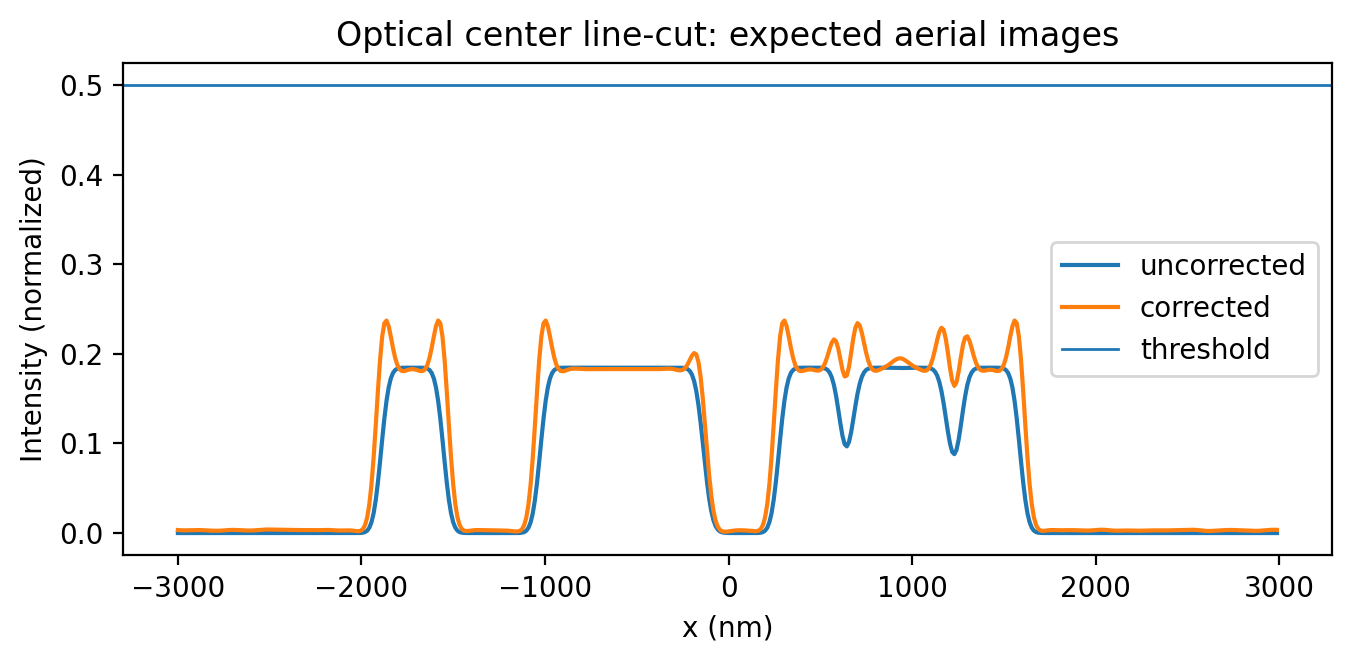

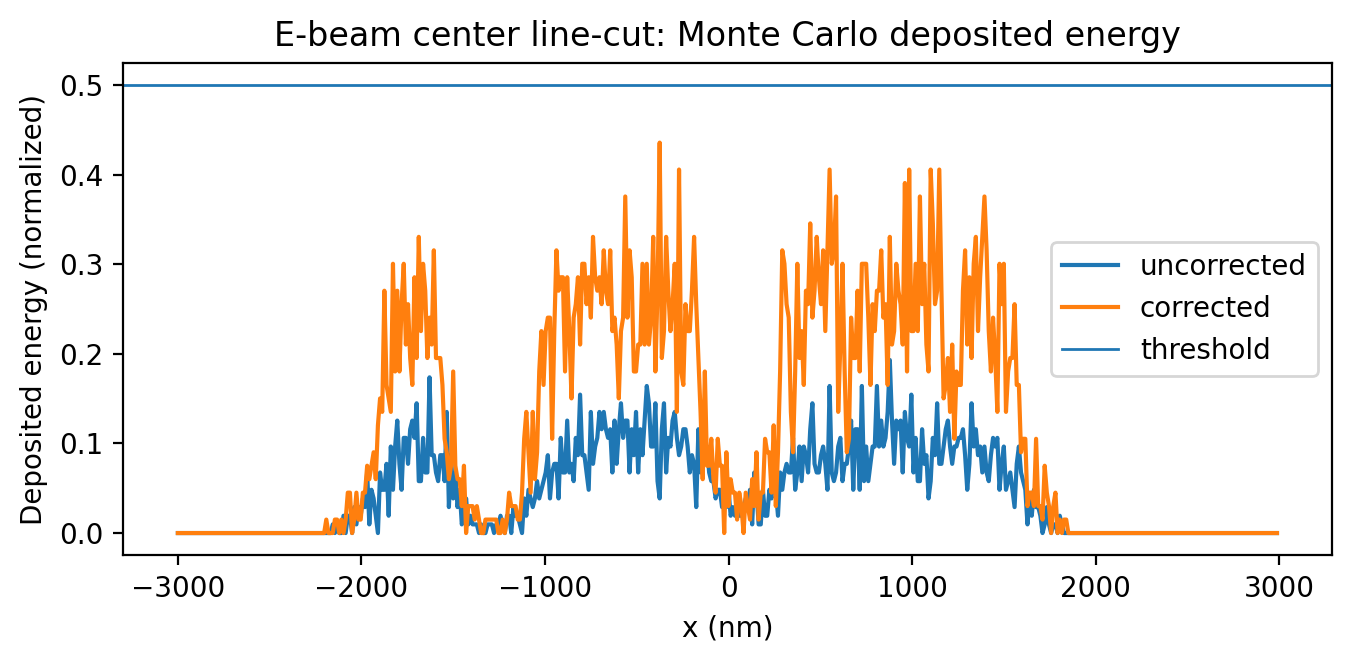

In [ ]:
y0 = CFG.grid_n // 2
x_nm = (np.arange(CFG.grid_n) - CFG.grid_n // 2) * pixel_nm(CFG)

plt.figure(figsize=(7.8, 3.2))
plt.title("Optical center line-cut: expected aerial images")
plt.plot(x_nm, to_cpu(opt_expected_unc)[y0, :], label="uncorrected")
plt.plot(x_nm, to_cpu(opt_expected_cor)[y0, :], label="corrected")
plt.axhline(CFG.opt_threshold, linewidth=1.0, label="threshold")
plt.xlabel("x (nm)")
plt.ylabel("Intensity (normalized)")
plt.legend()
plt.show()

plt.figure(figsize=(7.8, 3.2))
plt.title("E-beam center line-cut: Monte Carlo deposited energy")
plt.plot(x_nm, to_cpu(eb_energy_mc_unc)[y0, :], label="uncorrected")
plt.plot(x_nm, to_cpu(eb_energy_mc_cor)[y0, :], label="corrected")
plt.axhline(CFG.eb_threshold, linewidth=1.0, label="threshold")
plt.xlabel("x (nm)")
plt.ylabel("Deposited energy (normalized)")
plt.legend()
plt.show()